# Quantum Computing Lab - Assignment 2
## Mrudula A Mahindrakar
## EE25S011

In [1]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit import transpile
from qiskit_aer import AerSimulator, Aer
from qiskit.visualization import plot_histogram, plot_state_city, plot_bloch_multivector
from qiskit.quantum_info import Statevector, DensityMatrix, Operator, state_fidelity, partial_trace

from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

import numpy as np
from IPython.display import display


In [2]:
QiskitRuntimeService.save_account(
token="xkJWv4VN7ovAwCjwPGmyUi__YQnwd_JUdrDQruOzfHAs", # Use the 44-character API_KEY you created and saved from the IBM Quantum Platform Home dashboard
instance="crn:v1:bluemix:public:quantum-computing:us-east:a/fc6d0f6ae5bc4626a513c4e22ca728ff:667e7737-b264-44a4-aba8-02f96203b7bd::", # Optional: Use the CRN you created and saved from the IBM Quantum Platform Home dashboard
channel="ibm_cloud", # Optional: Use "ibm_quantum" for public access or "ibm_quantum_private" for private access
overwrite=True # Optional: Overwrite existing saved accounts
)
service = QiskitRuntimeService(channel="ibm_cloud")
print(service.backends())  # list available backends

backend = service.least_busy(operational=True, simulator=False, min_num_qubits = 127)
sim_backend = AerSimulator() # Use simulator by default

print(backend.name)

[<IBMBackend('ibm_fez')>, <IBMBackend('ibm_torino')>, <IBMBackend('ibm_marrakesh')>]
ibm_torino


# Problem 1 - Decode Alice’s message - BB84
In this exercise you will build quantum circuits to encode and decode key bits as per the BB84 Quantum Key Distribution (QKD) scheme. The
overall idea is as follows.
## ALICE:
* Chooses a 100-bit long random string. This string decides whether she will encode the data in the Z or X basis.
* Chooses another string of 100 bits that will correspond to the raw key.
* Finally you will build a function for Alice to encode her raw key in the bases as per her random string.
## BOB:
* Chooses a 100-bit long random string.
* Next, make measurements on the state sent by Alice either in the X or Z basis, based on this random string.

Sifting: Choose only those mesurement values for which the basis choice of Alice and Bob match.

Decode: Finally use the sifted key to decrypt the given encrypted message!

In [3]:
n = 100
a_bits = np.random.randint(2, size=n)
a_bases = np.random.randint(2, size=n) 

# 0 corresponds to Z basis
# 1 corresponds to X basis
def encoder(bits, bases):
    message = []
    for i in range(n):
        qc = QuantumCircuit(1, 1)
        if bases[i] == 0: 
            # Z-basis
            if bits[i] == 1:
                qc.x(0)
        else: 
            # X-basis
            if bits[i] == 0:
                qc.h(0)
            else:
                qc.x(0)
                qc.h(0)
        qc.barrier()
        message.append(qc)
    return message

encoded_qubits = encoder(a_bits, a_bases)

In [4]:
b_bases = np.random.randint(2, size=n)

def measurement(message, bases, backend):
    #backend = Aer.get_backend('qasm_simulator')
    pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
    
    isa_circuits = []
    for i in range(len(message)):
        qc = message[i].copy()
        
        if bases[i] == 1:
            qc.h(0)
        qc.measure(0, 0)
        
        transpiled_qc = pm.run(qc)
        isa_circuits.append(transpiled_qc)    
        
    # Run simulation
    sampler = Sampler(mode=backend)
    job = sampler.run(isa_circuits, shots=1024)
    print(f"Job ID: {job.job_id()}")

    result = job.result()

    measurements = []
    for i in range(len(message)):
        data = result[i].data
        reg_name = list(data.keys())[0]
        counts = data[reg_name].get_counts()
        bitstring = max(counts, key=counts.get)
        measured_bit = int(bitstring[-1])
        measurements.append(measured_bit)

    return measurements

encoded_qubits = encoder(a_bits, a_bases)
b_results = measurement(encoded_qubits, b_bases, backend)

Job ID: d64q8h3traac73biqnl0


In [5]:
def sifting(a_bits, a_bases, b_bases, b_results):
    #key = []
    a_sifted_key = []
    b_sifted_key = []
    
    for i in range(len(a_bases)):
        # If the bases match, we keep the bits
        if a_bases[i] == b_bases[i]:
            a_sifted_key.append(a_bits[i])
            b_sifted_key.append(b_results[i])
    return a_sifted_key, b_sifted_key

a_sifted_key, b_sifted_key = sifting(a_bits, a_bases, b_bases, b_results)
print(f"Keys match: {a_sifted_key == b_sifted_key}")

Keys match: True


In [6]:
def decryption(encrypted_bits, key):

    # considering the new shorter key
    length = min(len(encrypted_bits), len(key))
        
    decrypted_bits = []
    for i in range(length):
        decrypted_bit = encrypted_bits[i] ^ key[i] # XOR operation
        decrypted_bits.append(decrypted_bit)

    decrypted_text = ""
    # Convert bits to characters
    
    for i in range(0, len(decrypted_bits), 8):
        byte = decrypted_bits[i:i+8]
        char_code = int("".join(map(str, byte)), 2)
        decrypted_text += chr(char_code)
        
    return decrypted_text 

In [7]:
original_message = "heLLo" 

message_bits = []
for ch in original_message:
    binary = format(ord(ch), '08b')
    message_bits.extend([int(b) for b in binary])

if len(message_bits) > len(a_sifted_key):
    print(f"Warning: Message ({len(message_bits)} bits) is longer than key ({len(a_sifted_key)} bits). Truncating message.")
    message_bits = message_bits[:len(a_sifted_key)]

encrypted_message = [message_bits[i] ^ a_sifted_key[i] for i in range(len(message_bits))]

decrypted_text = decryption(encrypted_message, b_sifted_key)

print(f"Original: {original_message}")
print(f"Decrypted: {decrypted_text}")

Original: heLLo
Decrypted: heLLo


# Problem 2 Quantum Teleportation:
Create a quantum teleportation circuit. Telport the state of your choice, of the form α|0⟩+β|1⟩, with non-zero α and β. Please
clearly state -
1. Initial state that you are trying to teleport - in q0
2. Which qubits are entangled and which bell state you are using for the
teleportation - in q1 and q2.
3. The post processing i.e the unitary applied on q2 to get the encoded
state onto it.

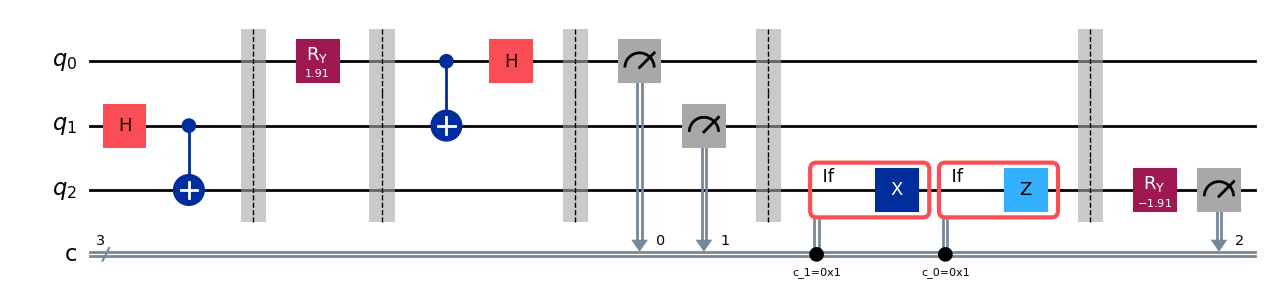

In [8]:
q = QuantumRegister(3, 'q')
c = ClassicalRegister(3, 'c')
qc = QuantumCircuit(q, c)


# Bell pair  on q1 and q2
qc.h(q[1])
qc.cx(q[1], q[2])
qc.barrier()

# state q0
theta = 2 * np.arccos(1/np.sqrt(3))
qc.ry(theta, q[0])
qc.barrier()


# entangling q0 and q1 bits
qc.cx(q[0], q[1])
qc.h(q[0])
qc.barrier()


# Measure q0 and q1
qc.measure(q[0], c[0])
qc.measure(q[1], c[1])
qc.barrier()

# conditional logic
with qc.if_test((c[1], 1)):  # 01
    qc.x(q[2])

with qc.if_test((c[0], 1)):  # 10
    qc.z(q[2])

qc.barrier()

qc.ry(theta, q[2]).inverse()
qc.measure(q[2], c[2])

qc.draw(output="mpl")

Job ID: d64qcins6ggc73fjg24g


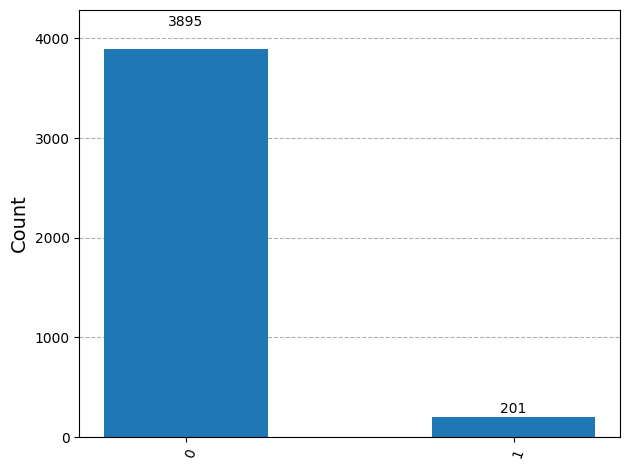

In [10]:
cr_result = ClassicalRegister(1,name="result")
qc.add_register(cr_result)
qc.measure(2, cr_result)

pm = generate_preset_pass_manager(target=backend.target, optimization_level=3)
qc_isa = pm.run(qc)

sampler = Sampler(mode=backend)
job = sampler.run([qc_isa])
print(f"Job ID: {job.job_id()}")

res = job.result()
counts = res[0].data.result.get_counts() 

plot_histogram(counts)

In [11]:
results = job.result()[0].data.c.get_counts()

success_count = 0
total_count = sum(results.values())

for bitstring, count in results.items():
    if bitstring[0] == '0': 
        success_count += count

fidelity = (success_count / total_count) * 100
print(f"Teleportation Fidelity: {fidelity:.2f}%")

Teleportation Fidelity: 94.75%


## Quantum Teleportation Summary

### 1. Initial State Teleported (q0)

The state prepared on qubit **q0** is a general superposition $|\psi\rangle = \alpha |0\rangle + \beta |1\rangle$ where the circuit applies an $ R_y(\theta) $ rotation with $ \theta = 2\cos^{-1}\left(\frac{1}{\sqrt{3}}\right) $

This creates the state $|\psi\rangle = \frac{1}{\sqrt{3}}|0\rangle + \sqrt{\frac{2}{3}}|1\rangle$ with non-zero amplitudes as mentioned.


### 2. Entangled Qubits and Bell State

Qubits **q1** and **q2** are entangled using a Hadamard gate on q1 followed by a CNOT (q1 → q2).  
This prepares the Bell state $ |\Phi^+\rangle = \frac{1}{\sqrt{2}} (|00\rangle + |11\rangle) $


### 3. Post-Processing on q2

After measuring q0 and q1, conditional operations are applied to q2:

| Measurement Result | Operation on q2 |
|--------------------|-----------------|
| 00 | I       |
| 01 | X gate  |
| 10 | Z gate  |
| 11 | X and Z |

These conditional operations reconstruct the original state  $\frac{1}{\sqrt{3}}|0\rangle + \sqrt{\frac{2}{3}}|1\rangle$ on q2.

### 4. Verification

An inverse $R_y(\theta)$ gate is applied to q2 before measurement.  
If teleportation is successful, this returns q2 to $|0\rangle$, so the final measurement gives 0 with high probability.


# Problem 3: Quantum teleportation using GHZ-like state
This exercise is based on the idea on reference [https://www.cs.memphis.edu/kanyang/paper/JIJTP.pdf]. In this teleportation protocol, Alice distributes a GHZ-like state
given as, $1/2(|001\rangle + |010\rangle + |100\rangle + |111\rangle)$.

The state that she would like to transfer is say, $α|0\rangle + β|1\rangle$. This state
can either be transfered to Bob or Charlie while the other party acts as an
controller. 
For example, here are the steps to get the state teleported from Alice to Charlie.
* Do a Bell measurement on the first two qubits with Alice
* Do a Z basis measurement on the third qubit, the qubit with Bob.
* Based on the results from Alice’s Bell measurement and Bob’s Z basis measurement apply local unitary on 3. Based on the results from Alice’s Bell measurement and Bob’s Z basis measurement apply local unitary on Charlies qubit and show that the state is successfully teleported.

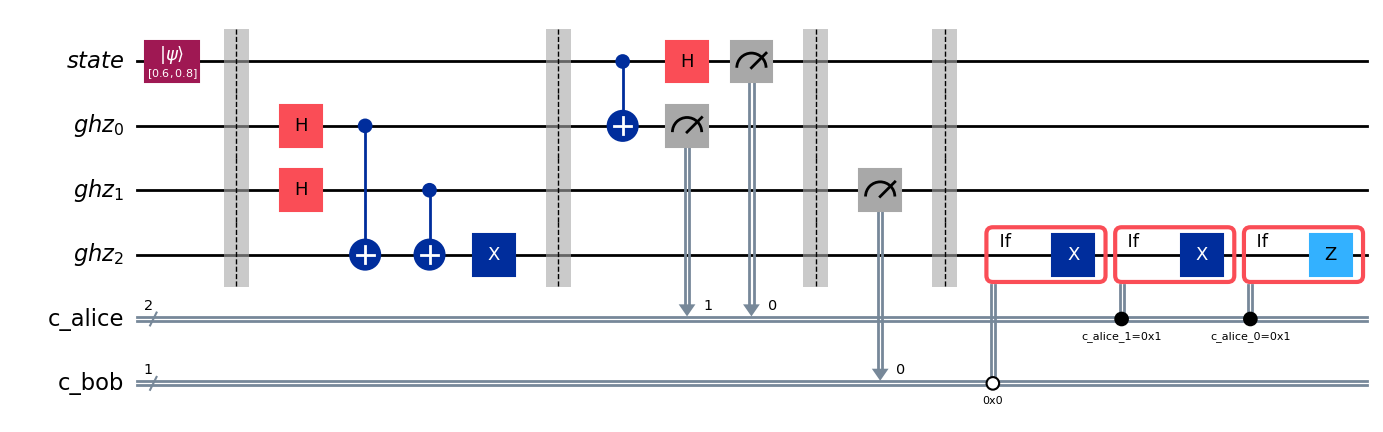

In [12]:
a_state = QuantumRegister(1, name="state")

# the GHZ-like state with q0 for Alice, q1 for Bob and q2:= for Charlie
q_ghz = QuantumRegister(3,name="ghz")
c_alice = ClassicalRegister(2,name="c_alice")
c_bob = ClassicalRegister(1,name="c_bob")

qc = QuantumCircuit(a_state, q_ghz, c_alice, c_bob)

# ex. Let's say Alice wants to send 0.6|0> + 0.8|1>
qc.initialize([0.6, 0.8], a_state)
qc.barrier()

# circuit to create the state 1/2(|001> + |010> + |100> + |111>)
qc.h(q_ghz[0])
qc.h(q_ghz[1])
qc.cx(q_ghz[0], q_ghz[2])
qc.cx(q_ghz[1], q_ghz[2])
qc.x(q_ghz[2])
qc.barrier()

# bell measurement for alice
qc.cx(a_state, q_ghz[0])
qc.h(a_state)
qc.measure(a_state, c_alice[0])
qc.measure(q_ghz[0], c_alice[1])
qc.barrier()

# Z-basis measurement with bob
qc.measure(q_ghz[1], c_bob[0])
qc.barrier()

# charlie applies corrections based on measurements
with qc.if_test((c_bob, 0)):
    qc.x(q_ghz[2])

with qc.if_test((c_alice[1], 1)):
    qc.x(q_ghz[2])

with qc.if_test((c_alice[0], 1)):
    qc.z(q_ghz[2])

qc.draw('mpl')

### Controlled Quantum Teleportation using a GHZ-like State

We consider the GHZ-like entangled state distributed by Alice:

$ \vert \text{GHZ}\rangle_{123} =\frac{1}{2} \left( \vert 001\rangle + \vert 010\rangle + \vert 100\rangle +  \vert 111\rangle \right) $

Qubit ownership:
- Qubit 0: Alice (unknown state)
- Qubit 1: Alice (GHZ)
- Qubit 2: Bob (controller)
- Qubit 3: Charlie (receiver)


Alice possesses an unknown qubit $\vert \psi\rangle_0 = \alpha\vert 0\rangle + \beta \vert 1\rangle $

The total initial state is: 

$
\begin{aligned}
\vert \Psi_0\rangle &= \vert \psi\rangle_0 \otimes \vert \text{GHZ}\rangle_{123} \\ 
&= \frac{1}{2}\Big( \alpha \vert 0\rangle( \vert 001\rangle+ \vert 010\rangle+ \vert 100\rangle+ \vert 111\rangle)+ \beta\vert 1\rangle( \vert001\rangle+ \vert 010\rangle+\vert 100\rangle+\vert111\rangle) \Big)
\end{aligned}
$

$ \vert \Psi_0\rangle = \frac{1}{2}( \alpha\vert 0001\rangle + \alpha\vert 0010\rangle + \alpha \vert 0100\rangle + \alpha\vert 0111\rangle + \beta\vert 1001\rangle + \beta\vert 1010\rangle + \beta\vert 1100\rangle + \beta \vert 1111\rangle ) $


Alice Performs Bell Measurement on Qubits (0,1)

$
\begin{aligned}
\vert \Phi^\pm\rangle &= \frac{1}{\sqrt{2}}(\vert 00\rangle \pm \vert 11\rangle) \\
\vert \Psi^\pm\rangle &= \frac{1}{\sqrt{2}}(\vert 01\rangle \pm \vert 10\rangle)
\end{aligned}
$

Rewrite the state in the Bell basis of qubits (0,1):

$
\vert\Psi\rangle =
\frac{1}{2\sqrt{2}}\sum_{\text{Bell}}
\vert\text{Bell}\rangle_{01}
\otimes
\vert \chi_{\text{Bell}}\rangle_{23}
$

where the conditional states are:
$
\begin{aligned}
\vert \chi_{\Phi^+}\rangle &= \alpha(\vert 01\rangle+\vert10\rangle) + \beta(\vert 00\rangle+\vert 11\rangle) \\
\vert \chi_{\Phi^-}\rangle &= \alpha(\vert 01\rangle+\vert 10\rangle) - \beta(\vert 00\rangle+\vert 11\rangle) \\
\vert \chi_{\Psi^+}\rangle &= \beta(\vert 01\rangle+\vert 10\rangle) + \alpha(\vert 00\rangle+\vert 11\rangle) \\
\vert \chi_{\Psi^-}\rangle &= \beta(\vert 01\rangle+\vert 10\rangle) - \alpha(\vert 00\rangle+\vert 11\rangle)
\end{aligned}
$

Bob performs a Z-basis measurement on qubit 2.


Charlie’s Collapsed States and Corrections


| Alice Bell State | Bob Z Result | Charlie’s State | Correction |
|------------------|--------------|-----------------|------------|
| $ \Phi^+ $ | 0 | $ \alpha \vert 0\rangle + \beta \vert 1\rangle $ |  I  |
| $ \Phi^+ $ | 1 | $ \alpha \vert 1\rangle + \beta \vert 0\rangle $ |  X  |
| $ \Phi^- $ | 0 | $ \alpha \vert 0\rangle - \beta \vert 1\rangle $ |  Z  |
| $ \Phi^- $ | 1 | $ \alpha \vert 1\rangle - \beta \vert 0\rangle $ |  ZX  |
| $ \Psi^+ $ | 0 | $ \beta \vert 0\rangle + \alpha \vert 1\rangle $ |  X  |
| $ \Psi^+ $ | 1 | $ \beta \vert 1\rangle + \alpha \vert 0\rangle $ |  I  |
| $ \Psi^- $ | 0 | $ \beta \vert 0\rangle - \alpha \vert 1\rangle $ |  ZX  |
| $ \Psi^- $ | 1 | $ \beta \vert 1\rangle - \alpha \vert 0\rangle $ |  Z  |


Let Alice’s Bell bits be c0 and c1, and Bob's classical bit be c_b.

Corrections applied by Charlie are $ X \quad \text{if } (c_1 \oplus c_b) = 1 $ and $ Z \quad \text{if } c_0 = 1 $ 

After applying these corrections, the state of charlie will be $ \alpha \vert 0\rangle + \beta \vert 1\rangle $

In [155]:
simulator = AerSimulator()

qc.save_statevector()

t_qc = transpile(qc, simulator)
result = simulator.run(t_qc).result()
final_statevector = result.get_statevector()

target_state = Statevector([0.6, 0.8])

charlie_state = final_statevector.probabilities_dict([3])

print(f"Target probabilities: {{'0': {0.6**2:.2f}, '1': {0.8**2:.2f}}}")
print(f"Charlie's actual probabilities: {charlie_state}")

final_density_matrix = partial_trace(final_statevector, [0, 1, 2])
fidelity = state_fidelity(target_state, final_density_matrix)

print(f"\nTeleportation Fidelity: {fidelity:.4f}")

Target probabilities: {'0': 0.36, '1': 0.64}
Charlie's actual probabilities: {np.str_('0'): np.float64(0.36), np.str_('1'): np.float64(0.6399999999999999)}

Teleportation Fidelity: 1.0000
